# MIL-CREDA frente a CREDA — fase uno: la escalera

Diez métodos sobre seis transferencias. Cada peldaño se diferencia del anterior en
**una sola cosa**, así una diferencia se puede atribuir a esa cosa y a ninguna otra.

El nombre dice qué le falta al método: un asterisco marca un componente ausente,
dos marcan dos, y un nombre sin marca es el método completo.

| id | nombre | adaptación | ponderación | término local | instancias que usa |
|---|---|---|---|---|---|
| `A` | `Baseline` | — | — | — | todas |
| `C` | `CREDA*` | CREDA | — | — | todas |
| `D` | `CREDA` | CREDA | sí | — | todas |
| `B` | `MIL-Baseline` | — | — | — | todas |
| `E` | `MIL-CREDA**` | MIL-CREDA | — | — | todas |
| `F` | `MIL-CREDA*` | MIL-CREDA | sí | — | todas |
| `G` | `MIL-CREDA` | MIL-CREDA | sí | sí | todas |
| `SU` | `MIL-CREDA-U` | MIL-CREDA | sí | sí | 10, selección regular |
| `SA` | `MIL-CREDA-A` | MIL-CREDA | sí | sí | 10, selección arbitraria |
| `SK` | `MIL-CREDA-K` | MIL-CREDA | sí | sí | 10, las de mayor atención |

Los últimos tres mantienen fijo el presupuesto de instancias y se diferencian solo
en la regla que lo gasta, así que `MIL-CREDA-U → MIL-CREDA-K` y
`MIL-CREDA-A → MIL-CREDA-K` son atribuibles a la regla. `MIL-CREDA-K → MIL-CREDA`
es la pregunta aparte de cuánto cuesta el presupuesto en sí.

Todo lo de abajo está acotado por `config.py`, y solo dos constantes separan esta
corrida de la completa. **Leer el encabezado de cada tabla antes que sus números**:
por debajo del piso de repeticiones declarado no se otorga ningún veredicto y el
motivo queda estampado.

In [1]:
# Bootstrap: locate the repository wherever this is running, and import from it.
# Local, Colab and Kaggle differ only in where the checkout sits.
import os
import sys
from pathlib import Path


def find_repository() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for base in (os.environ.get("MIL_CREDA_REPO", ""), "/content", "/kaggle/working"):
        if base and Path(base).is_dir():
            candidates.append(Path(base))
            candidates.extend(sorted(Path(base).glob("*")))
    for candidate in candidates:
        if (candidate / "src" / "MIL_CREDA_Benchmark").is_dir():
            return candidate.resolve()
    raise SystemExit(
        "cannot find the repository. Set MIL_CREDA_REPO to the checkout that "
        "holds src/MIL_CREDA_Benchmark, or run this notebook from inside it."
    )


REPOSITORY = find_repository()
sys.path.insert(0, str(REPOSITORY / "src"))
print("repository:", REPOSITORY)

repository: /Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation


In [2]:
import json
import time

from IPython.display import Markdown, display

from MIL_CREDA_Benchmark import config, harness


def show(text: str) -> None:
    """Una tabla se muestra como tabla, no como texto de ancho fijo.

    Es la misma cadena que va al registro, renderizada. Nada se vuelve a
    calcular acá: si esto y el archivo dijeran cosas distintas, habría dos
    versiones del mismo número y ninguna forma de saber cuál se movió.
    """
    display(Markdown(text))


device = harness.resolve_device()
reduction = harness.Reduction(device=str(device), environment=harness.environment())

shape = config.sizing()
print(json.dumps(shape, indent=2))
print()
print(harness.header(reduction))
print()
print("environment:", reduction.environment["platform"],
      "| torch", reduction.environment["torch"],
      "| self-hosted" if reduction.environment["selfHosted"] else "| hosted runtime")

{
  "arms": 10,
  "transfers": 6,
  "seeds": 1,
  "runs": 60,
  "epochs": 3,
  "stepsPerEpoch": 7,
  "imagesPerStep": 300,
  "imagePassesPerRun": 12600,
  "verdictsMeaningful": false
}

setting=trained  backbone=resnet18  bags=100x30  split=64/36  epochs=3  seeds=1  device=mps  revision=research-concept-r17.md
!! 1 repetition(s): the dispersion is zero, so the threshold is zero and every row below declares a winner from a bare difference. These are point estimates, not verdicts.

environment: macOS-26.5.2-arm64-arm-64bit | torch 2.13.0 | self-hosted


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# One run, timed, before committing to the whole grid. An estimate of the cost is
# cheaper than the cost, so it happens first.
from MIL_CREDA_Benchmark import bags

material = {role: bags.build(code, config.DATA_CACHE, config.SEEDS[0])
            for role, code in zip(("source", "target"), config.TRANSFERS[0])}
probe = harness.run_one("G", config.TRANSFERS[0], config.SEEDS[0],
                        reduction, device, material)
per_run = probe["seconds"]
full = len(config.ARMS) * len(config.TRANSFERS) * 30 * per_run * 20 / reduction.epochs
print(f"one full arm, {reduction.epochs} epochs: {per_run:.1f}s")
print(f"this grid ({shape['runs']} runs): about {shape['runs'] * per_run / 60:.0f} min")
print(f"at 20 epochs and 30 seeds: about {full / 3600:.0f} h")
del material, probe

one full arm, 3 epochs: 14.1s
this grid (60 runs): about 14 min
at 20 epochs and 30 seeds: about 47 h


## La corrida

Una línea por transferencia, no una por corrida: con treinta semillas la lista
completa serían mil ochocientas líneas y todo lo que dicen ya está en las tablas
de más abajo. Esta salida existe para saber que la campaña sigue viva, nada más.

In [4]:
seen = {"n": 0}

def progress(line: str) -> None:
    seen["n"] += 1
    if seen["n"] % len(config.ARMS) == 0:
        print(f"  {seen['n']:>5}/{shape['runs']} corridas "
              f"({(time.perf_counter() - started) / 60:.1f} min)")

started = time.perf_counter()
summary = harness.campaign(reduction, device, progress=progress)
runs = [json.loads(line) for line in
        (config.RESULTS / "runs.jsonl").read_text().splitlines() if line.strip()]
print(f"\ncampaña terminada en {(time.perf_counter() - started) / 60:.1f} min, "
      f"{len(runs)} corridas")

     10/60 corridas (1.9 min)


     20/60 corridas (3.7 min)


     30/60 corridas (5.5 min)


     40/60 corridas (7.3 min)


     50/60 corridas (9.1 min)


     60/60 corridas (10.9 min)

campaña terminada en 10.9 min, 60 corridas


## Bajo qué corrió todo esto

Los límites de la corrida se dicen una vez, acá, y atan todo lo que sigue. No se
repiten en el encabezado de cada tabla: un aviso que aparece ocho veces enseña a
saltearlo, que es lo contrario de para lo que está.

In [5]:
from MIL_CREDA_Benchmark import tables

show(tables.stamp(summary["reduction"], markdown=True))

> resnet18  ·  3 épocas  ·  1 repetición(es)  ·  research-concept-r17.md  
> la exactitud se mueve de a 2.78 puntos sobre 36 bolsas de evaluación: nada por debajo de eso lo resuelve una transferencia sola  
> !! 1 repetición(es): el ± de abajo es cero por construcción, no por acuerdo. Son estimaciones puntuales, no resultados.  
> !! piloto: el protocolo declara 30 repeticiones y 20 épocas. Nada de esto es un resultado.  

## 1 · Tiempo de entrenamiento

Los segundos que tarda una corrida completa de cada método en cada transferencia,
con la misma máquina, el mismo backbone y la misma cantidad de pasos. Va primero
porque un método que gana pagando diez veces el cómputo no gana lo mismo que uno que
gana gratis, y porque el costo es lo único que se compara limpio aunque las dos
familias predigan sobre unidades distintas. Buscamos el número más bajo, y sobre
todo que la diferencia entre métodos sea chica: un método más lento sigue siendo
utilizable, uno diez veces más lento deja de serlo.

In [6]:
show(tables.objective("seconds"))

> **Buscamos el número más bajo**, y sobre todo que la diferencia entre métodos sea chica: uno más lento sigue siendo utilizable, uno diez veces más lento deja de serlo.

In [7]:
show(tables.render(runs, "seconds", summary["reduction"], markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 4.82 ± 0.00 | 4.82 ± 0.00 | 4.68 ± 0.00 | 4.68 ± 0.00 | 4.67 ± 0.00 | 4.69 ± 0.00 | **4.73** |
| `CREDA*` | 10.68 ± 0.00 | 8.98 ± 0.00 | 8.73 ± 0.00 | 8.86 ± 0.00 | 8.66 ± 0.00 | 8.79 ± 0.00 | **9.12** |
| `CREDA` | 8.98 ± 0.00 | 8.80 ± 0.00 | 8.69 ± 0.00 | 9.38 ± 0.00 | 8.74 ± 0.00 | 9.24 ± 0.00 | **8.97** |
| `MIL-Baseline` | 4.86 ± 0.00 | 4.79 ± 0.00 | 4.77 ± 0.00 | 4.80 ± 0.00 | 4.76 ± 0.00 | 4.77 ± 0.00 | **4.79** |
| `MIL-CREDA**` | 12.40 ± 0.00 | 12.38 ± 0.00 | 12.60 ± 0.00 | 12.53 ± 0.00 | 12.28 ± 0.00 | 12.40 ± 0.00 | **12.43** |
| `MIL-CREDA*` | 12.07 ± 0.00 | 12.58 ± 0.00 | 12.46 ± 0.00 | 12.81 ± 0.00 | 12.42 ± 0.00 | 12.13 ± 0.00 | **12.41** |
| `MIL-CREDA` | 13.49 ± 0.00 | 13.42 ± 0.00 | 13.44 ± 0.00 | 13.61 ± 0.00 | 13.18 ± 0.00 | 13.46 ± 0.00 | **13.43** |
| `MIL-CREDA-U` | 13.41 ± 0.00 | 13.17 ± 0.00 | 13.04 ± 0.00 | 13.05 ± 0.00 | 12.80 ± 0.00 | 12.87 ± 0.00 | **13.06** |
| `MIL-CREDA-A` | 12.93 ± 0.00 | 13.21 ± 0.00 | 13.20 ± 0.00 | 12.93 ± 0.00 | 13.09 ± 0.00 | 13.11 ± 0.00 | **13.08** |
| `MIL-CREDA-K` | 13.42 ± 0.00 | 13.17 ± 0.00 | 13.09 ± 0.00 | 12.99 ± 0.00 | 12.78 ± 0.00 | 12.46 ± 0.00 | **12.99** |

In [8]:
show(tables.conclusion(runs, "seconds", summary["reduction"]))

Mejor promedio: **Baseline** con 4.73s; peor: MIL-CREDA con 13.43s. CREDA queda 4.25s por debajo de su piso Baseline. MIL-CREDA queda 8.64s por debajo de su piso MIL-Baseline. Con 1 repetición(es) esto es una estimación puntual y no un veredicto: la dispersión es cero por construcción, no por acuerdo. Más repeticiones lo refuerzan o lo cambian.

## 2 · Exactitud en el dominio fuente

La proporción de bolsas de evaluación del dominio **fuente** que cada método
clasifica bien: el dominio cuyas etiquetas sí vio durante el entrenamiento. Va antes
que la de destino porque es su complemento, y sin ella la tabla de destino no
distingue un éxito de una degeneración — un método que sube en destino rompiendo la
fuente aparece como ganador si solo se mira una tabla. Buscamos que sea alta, y
sobre todo que **no caiga** cuando se le suma la adaptación.

In [9]:
show(tables.objective("sourceAccuracy"))

> **Buscamos que sea alta y que no caiga** al sumar la adaptación. El piso es el azar de acertar una clase entre 10, o sea 0.100; el techo es 1.000.

In [10]:
show(tables.render(runs, "sourceAccuracy", summary["reduction"], markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 41.7 ± 0.0 | 100.0 ± 0.0 | 50.0 ± 0.0 | **81.9** |
| `CREDA*` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 41.7 ± 0.0 | 100.0 ± 0.0 | 50.0 ± 0.0 | **81.9** |
| `CREDA` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 38.9 ± 0.0 | 100.0 ± 0.0 | 50.0 ± 0.0 | **81.5** |
| `MIL-Baseline` | 100.0 ± 0.0 | 97.2 ± 0.0 | 97.2 ± 0.0 | 19.4 ± 0.0 | 91.7 ± 0.0 | 38.9 ± 0.0 | **74.1** |
| `MIL-CREDA**` | 100.0 ± 0.0 | 100.0 ± 0.0 | 91.7 ± 0.0 | 22.2 ± 0.0 | 69.4 ± 0.0 | 38.9 ± 0.0 | **70.4** |
| `MIL-CREDA*` | 91.7 ± 0.0 | 77.8 ± 0.0 | 91.7 ± 0.0 | 22.2 ± 0.0 | 77.8 ± 0.0 | 30.6 ± 0.0 | **65.3** |
| `MIL-CREDA` | 86.1 ± 0.0 | 100.0 ± 0.0 | 66.7 ± 0.0 | 27.8 ± 0.0 | 88.9 ± 0.0 | 33.3 ± 0.0 | **67.1** |
| `MIL-CREDA-U` | 80.6 ± 0.0 | 69.4 ± 0.0 | 77.8 ± 0.0 | 8.3 ± 0.0 | 66.7 ± 0.0 | 25.0 ± 0.0 | **54.6** |
| `MIL-CREDA-A` | 66.7 ± 0.0 | 94.4 ± 0.0 | 86.1 ± 0.0 | 8.3 ± 0.0 | 83.3 ± 0.0 | 5.6 ± 0.0 | **57.4** |
| `MIL-CREDA-K` | 86.1 ± 0.0 | 80.6 ± 0.0 | 83.3 ± 0.0 | 19.4 ± 0.0 | 75.0 ± 0.0 | 22.2 ± 0.0 | **61.1** |

In [11]:
show(tables.conclusion(runs, "sourceAccuracy", summary["reduction"]))

Mejor promedio: **Baseline** con 81.9%; peor: MIL-CREDA-U con 54.6%. CREDA queda 0.5% por debajo de su piso Baseline. MIL-CREDA queda 6.9% por debajo de su piso MIL-Baseline. Con 1 repetición(es) esto es una estimación puntual y no un veredicto: la dispersión es cero por construcción, no por acuerdo. Más repeticiones lo refuerzan o lo cambian.

### 2b · Los peldaños en fuente

La diferencia entre los dos métodos de cada peldaño, transferencia por transferencia,
restada en el orden en que el peldaño se nombra: izquierda menos derecha. Un valor
**negativo** quiere decir que el de la derecha quedó por encima. La tabla anterior
dice quién está adelante; solo esta dice **qué componente** lo puso ahí, porque los
dos métodos de un peldaño se diferencian en una sola cosa. Buscamos peldaños que se
inclinen para el mismo lado en las seis transferencias: una media que promedia seis
acuerdos y una que promedia tres contra tres se ven idénticas y dicen cosas opuestas.

In [12]:
show(tables.objective("rungs"))

> **Buscamos acuerdo, no magnitud**: que el peldaño se incline para el mismo lado en las 6 transferencias, o sea 6/6 o 0/6. Cualquier cosa entre medio —3/6, por ejemplo— promedia parecido y no dice nada.

In [13]:
show(tables.render_rungs(summary, "sourceAccuracy", markdown=True))

| Peldaño | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | gana izq. |
|---|---|---|---|---|---|---|---|---|
| Baseline → MIL-Baseline | +0.0 | +2.8 | +2.8 | +22.2 | +8.3 | +11.1 | **+7.9** | 5/6 |
| Baseline → CREDA* | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| CREDA* → CREDA | +0.0 | +0.0 | +0.0 | +2.8 | +0.0 | +0.0 | **+0.5** | 1/6 |
| MIL-Baseline → MIL-CREDA** | +0.0 | -2.8 | +5.6 | -2.8 | +22.2 | +0.0 | **+3.7** | 2/6 |
| MIL-CREDA** → MIL-CREDA* | +8.3 | +22.2 | +0.0 | +0.0 | -8.3 | +8.3 | **+5.1** | 3/6 |
| MIL-CREDA* → MIL-CREDA | +5.6 | -22.2 | +25.0 | -5.6 | -11.1 | -2.8 | **-1.9** | 2/6 |
| CREDA* → MIL-CREDA** | +0.0 | +0.0 | +8.3 | +19.4 | +30.6 | +11.1 | **+11.6** | 4/6 |
| CREDA → MIL-CREDA* | +8.3 | +22.2 | +8.3 | +16.7 | +22.2 | +19.4 | **+16.2** | 6/6 |
| CREDA → MIL-CREDA | +13.9 | +0.0 | +33.3 | +11.1 | +11.1 | +16.7 | **+14.4** | 5/6 |
| MIL-CREDA-U → MIL-CREDA-K | -5.6 | -11.1 | -5.6 | -11.1 | -8.3 | +2.8 | **-6.5** | 1/6 |
| MIL-CREDA-A → MIL-CREDA-K | -19.4 | +13.9 | +2.8 | -11.1 | +8.3 | -16.7 | **-3.7** | 3/6 |
| MIL-CREDA-K → MIL-CREDA | +0.0 | -19.4 | +16.7 | -8.3 | -13.9 | -11.1 | **-6.0** | 1/6 |

In [14]:
show(tables.conclusion_rungs(summary, "sourceAccuracy"))

El peldaño que más separa es **CREDA → MIL-CREDA***: **CREDA** queda 16.2 por encima de MIL-CREDA*, y eso lee el mismo peldaño, construido de dos maneras: ponderado. Se inclinan igual en las 6 transferencias: Baseline → CREDA*, CREDA → MIL-CREDA*. Con esta cantidad de repeticiones lo que carga peso es la coincidencia entre transferencias, no la magnitud: seis acuerdos y tres contra tres promedian parecido y dicen cosas distintas.

## 3 · Exactitud en el dominio destino

La proporción de bolsas de evaluación del dominio **destino** —aquel cuyas etiquetas
el método nunca vio— que clasifica bien. Es la pregunta del problema: todo lo demás
en este cuaderno existe para poder leer esta tabla sin equivocarse. Buscamos que sea
alta, leída siempre junto a la de fuente y nunca sola, porque una subida acá pagada
con una caída allá no es adaptación sino un intercambio.

In [15]:
show(tables.objective("targetAccuracy"))

> **Buscamos el valor más alto posible**, entre el azar de 0.100 y 1.000 — y leído junto a la tabla de fuente, porque una subida acá pagada con una caída allá no es adaptación.

In [16]:
show(tables.render(runs, "targetAccuracy", summary["reduction"], markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 77.8 ± 0.0 | 97.2 ± 0.0 | 8.3 ± 0.0 | 72.2 ± 0.0 | 19.4 ± 0.0 | 47.2 ± 0.0 | **53.7** |
| `CREDA*` | 83.3 ± 0.0 | 100.0 ± 0.0 | 8.3 ± 0.0 | 72.2 ± 0.0 | 22.2 ± 0.0 | 47.2 ± 0.0 | **55.6** |
| `CREDA` | 72.2 ± 0.0 | 97.2 ± 0.0 | 13.9 ± 0.0 | 52.8 ± 0.0 | 19.4 ± 0.0 | 36.1 ± 0.0 | **48.6** |
| `MIL-Baseline` | 63.9 ± 0.0 | 80.6 ± 0.0 | 19.4 ± 0.0 | 36.1 ± 0.0 | 13.9 ± 0.0 | 30.6 ± 0.0 | **40.7** |
| `MIL-CREDA**` | 66.7 ± 0.0 | 72.2 ± 0.0 | 16.7 ± 0.0 | 25.0 ± 0.0 | 16.7 ± 0.0 | 30.6 ± 0.0 | **38.0** |
| `MIL-CREDA*` | 58.3 ± 0.0 | 69.4 ± 0.0 | 27.8 ± 0.0 | 25.0 ± 0.0 | 8.3 ± 0.0 | 13.9 ± 0.0 | **33.8** |
| `MIL-CREDA` | 44.4 ± 0.0 | 66.7 ± 0.0 | 22.2 ± 0.0 | 27.8 ± 0.0 | 8.3 ± 0.0 | 19.4 ± 0.0 | **31.5** |
| `MIL-CREDA-U` | 19.4 ± 0.0 | 41.7 ± 0.0 | 13.9 ± 0.0 | 19.4 ± 0.0 | 11.1 ± 0.0 | 25.0 ± 0.0 | **21.8** |
| `MIL-CREDA-A` | 44.4 ± 0.0 | 50.0 ± 0.0 | 16.7 ± 0.0 | 19.4 ± 0.0 | 19.4 ± 0.0 | 22.2 ± 0.0 | **28.7** |
| `MIL-CREDA-K` | 38.9 ± 0.0 | 75.0 ± 0.0 | 16.7 ± 0.0 | 19.4 ± 0.0 | 11.1 ± 0.0 | 16.7 ± 0.0 | **29.6** |

In [17]:
show(tables.conclusion(runs, "targetAccuracy", summary["reduction"]))

Mejor promedio: **CREDA*** con 55.6%; peor: MIL-CREDA-U con 21.8%. CREDA queda 5.1% por debajo de su piso Baseline. MIL-CREDA queda 9.3% por debajo de su piso MIL-Baseline. Con 1 repetición(es) esto es una estimación puntual y no un veredicto: la dispersión es cero por construcción, no por acuerdo. Más repeticiones lo refuerzan o lo cambian.

### 3b · Los peldaños en destino

Lo mismo que 2b sobre el dominio destino, con la misma resta: izquierda menos
derecha, y un negativo es el de la derecha por encima. Acá es donde se lee qué aporta
cada componente al problema que se quiere resolver, así que buscamos lo mismo —
acuerdo entre las seis transferencias— con una lectura extra: un peldaño que se
inclina en fuente y no en destino es una diferencia que no llegó a donde importaba.

In [18]:
show(tables.objective("rungs"))

> **Buscamos acuerdo, no magnitud**: que el peldaño se incline para el mismo lado en las 6 transferencias, o sea 6/6 o 0/6. Cualquier cosa entre medio —3/6, por ejemplo— promedia parecido y no dice nada.

In [19]:
show(tables.render_rungs(summary, "targetAccuracy", markdown=True))

| Peldaño | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | gana izq. |
|---|---|---|---|---|---|---|---|---|
| Baseline → MIL-Baseline | +13.9 | +16.7 | -11.1 | +36.1 | +5.6 | +16.7 | **+13.0** | 5/6 |
| Baseline → CREDA* | -5.6 | -2.8 | +0.0 | +0.0 | -2.8 | +0.0 | **-1.9** | 0/6 |
| CREDA* → CREDA | +11.1 | +2.8 | -5.6 | +19.4 | +2.8 | +11.1 | **+6.9** | 5/6 |
| MIL-Baseline → MIL-CREDA** | -2.8 | +8.3 | +2.8 | +11.1 | -2.8 | +0.0 | **+2.8** | 3/6 |
| MIL-CREDA** → MIL-CREDA* | +8.3 | +2.8 | -11.1 | +0.0 | +8.3 | +16.7 | **+4.2** | 4/6 |
| MIL-CREDA* → MIL-CREDA | +13.9 | +2.8 | +5.6 | -2.8 | +0.0 | -5.6 | **+2.3** | 3/6 |
| CREDA* → MIL-CREDA** | +16.7 | +27.8 | -8.3 | +47.2 | +5.6 | +16.7 | **+17.6** | 5/6 |
| CREDA → MIL-CREDA* | +13.9 | +27.8 | -13.9 | +27.8 | +11.1 | +22.2 | **+14.8** | 5/6 |
| CREDA → MIL-CREDA | +27.8 | +30.6 | -8.3 | +25.0 | +11.1 | +16.7 | **+17.1** | 5/6 |
| MIL-CREDA-U → MIL-CREDA-K | -19.4 | -33.3 | -2.8 | +0.0 | +0.0 | +8.3 | **-7.9** | 1/6 |
| MIL-CREDA-A → MIL-CREDA-K | +5.6 | -25.0 | +0.0 | +0.0 | +8.3 | +5.6 | **-0.9** | 3/6 |
| MIL-CREDA-K → MIL-CREDA | -5.6 | +8.3 | -5.6 | -8.3 | +2.8 | -2.8 | **-1.9** | 2/6 |

In [20]:
show(tables.conclusion_rungs(summary, "targetAccuracy"))

El peldaño que más separa es **CREDA* → MIL-CREDA****: **CREDA*** queda 17.6 por encima de MIL-CREDA**, y eso lee el mismo peldaño, construido de dos maneras: sin ponderar. Se inclinan igual en las 6 transferencias: Baseline → CREDA*. Con esta cantidad de repeticiones lo que carga peso es la coincidencia entre transferencias, no la magnitud: seis acuerdos y tres contra tres promedian parecido y dicen cosas distintas.

In [21]:
from MIL_CREDA_Benchmark import figures

## 4 · Las curvas del término supervisado

El término supervisado a lo largo del entrenamiento, un panel por transferencia,
para los métodos que lo comparten con un término de adaptación. Acá aparece un
término de adaptación que desestabiliza el ajuste: leer la curva de adaptación
sola llamaría bien portado a un término mientras la clasificación con la que
comparte objetivo se deshace por debajo. Cada curva es la mediana entre semillas
con banda intercuartil, nunca una corrida sola. Buscamos que el ajuste no se
degrade cuando se le suma la adaptación.

In [22]:
show(tables.objective("supervised"))

> **Buscamos que la curva baje y se quede baja.** Que caiga más rápido es mejor, y que no se desestabilice al sumarle la adaptación: si el ajuste se deshace, el término de adaptación lo rompió.

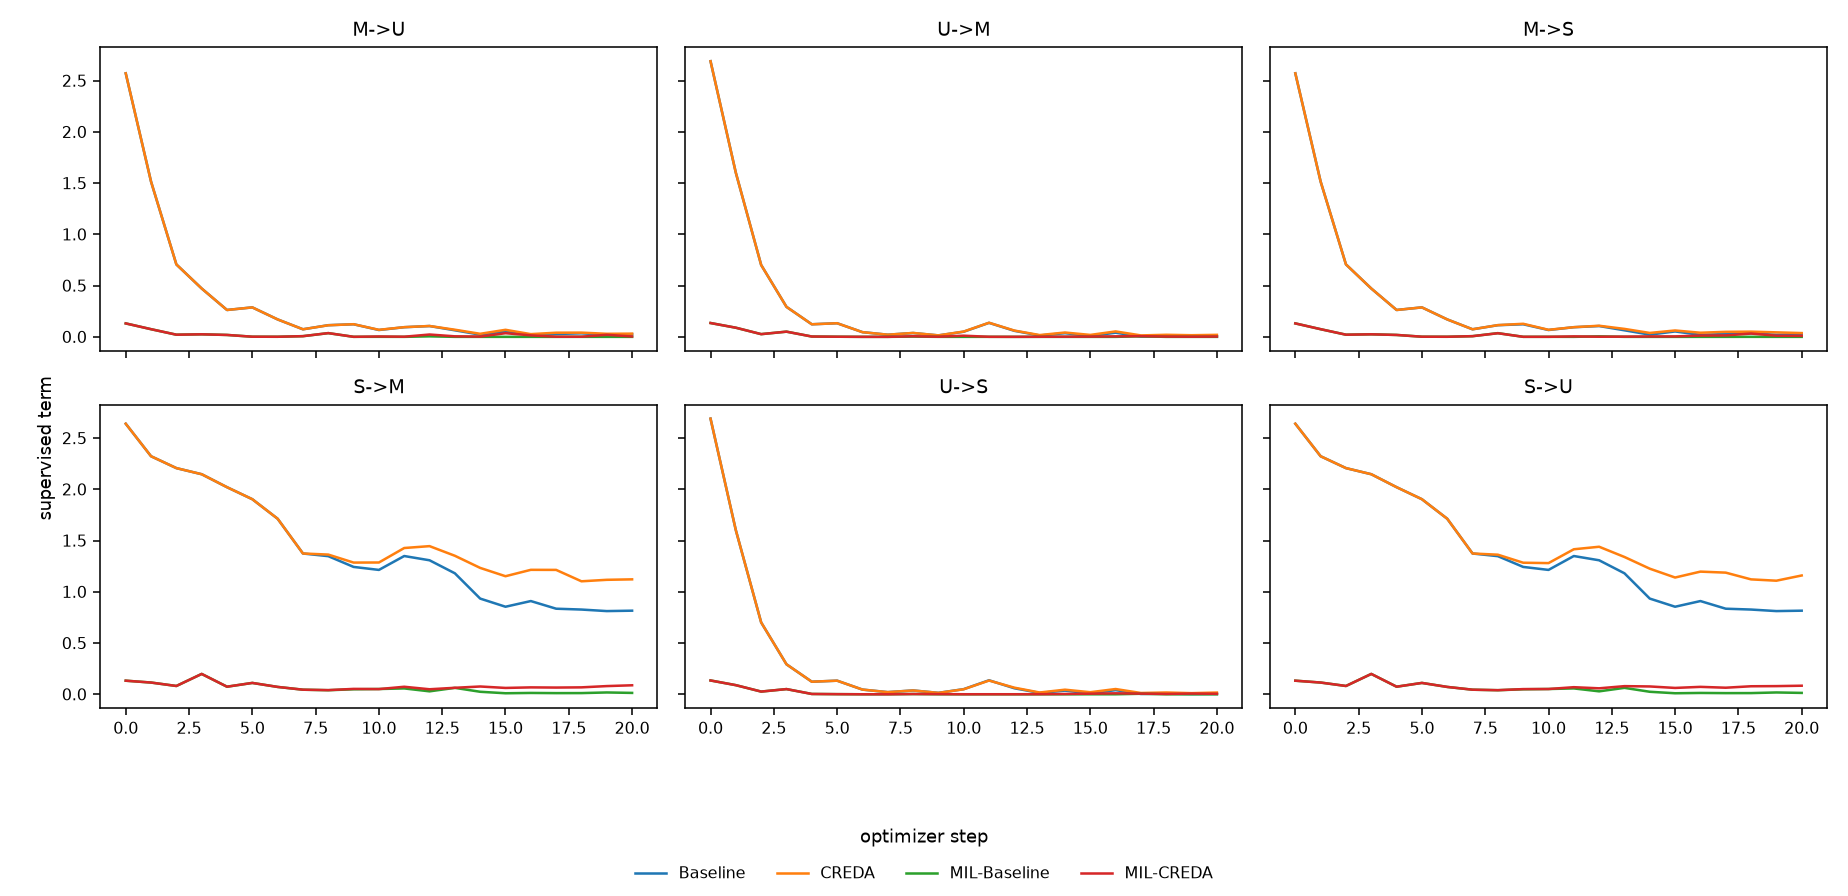

In [23]:
# Se muestra y se guarda en la misma llamada: la copia vectorial queda en Results
# y el cuaderno muestra la imagen, no su nombre de archivo.
display(figures.inline(figures.supervised_curves(config.RESULTS / "curves" / "supervised.pdf")))

## 5 · Las curvas del término de adaptación

Cuánto vale cada término de adaptación a lo largo del entrenamiento. La banda
sombreada es [0, 1]: la §5 normaliza los términos de MIL-CREDA exactamente sobre
ese intervalo y la puntuación del trabajo previo no tiene esa cota, así que si una
curva se queda adentro de la banda —y si ocupa la misma parte de ella de una
transferencia a otra— es la afirmación misma y no una ilustración de ella.
Buscamos curvas dentro de la banda y estables entre pares de dominios.

In [24]:
show(tables.objective("adaptation"))

> **Buscamos que la curva viva dentro de [0, 1] y tienda a cero**, y que ocupe la misma parte del intervalo en las seis transferencias. Salirse de la banda o cambiar de escala entre pares de dominios es el hallazgo.

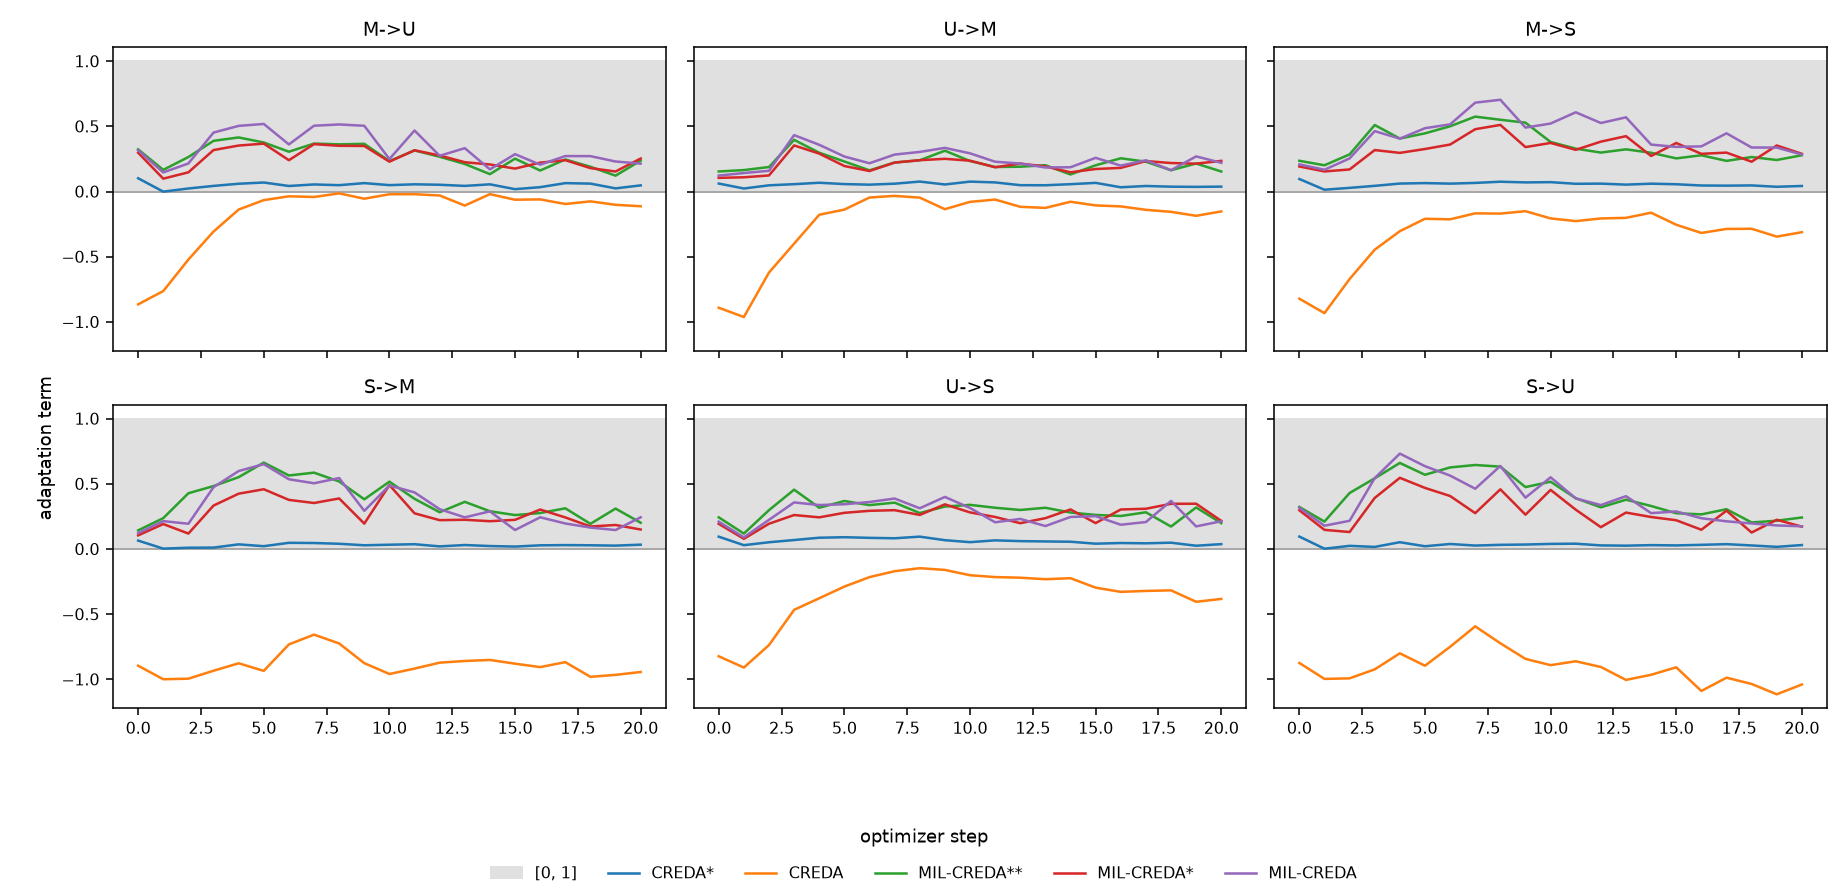

In [25]:
# Se muestra y se guarda en la misma llamada: la copia vectorial queda en Results
# y el cuaderno muestra la imagen, no su nombre de archivo.
display(figures.inline(figures.adaptation_curves(config.RESULTS / "curves" / "adaptation.pdf")))

## 6 · Cuánto del objetivo comanda cada término

Qué proporción del objetivo se lleva de verdad cada término declarado. Sin este
panel, «el término no tuvo efecto» y «el término no tuvo peso» son la misma
figura. El coeficiente está fijo en `LAMBDA_CONST` para todos los métodos, y fijar
el coeficiente no fija la proporción: un término cuya magnitud difiere en un orden
entre métodos es una diferencia que nadie declaró, y un peldaño que la ignora le
acredita al mecanismo lo que hizo la escala. Buscamos proporciones comparables
entre métodos, porque es lo que hace legible al peldaño.

In [26]:
show(tables.objective("contribution"))

> **Buscamos que ningún método quede en cero y que los valores sean comparables entre sí.** En cero, «el término no hizo nada» y «el término no pesó nada» son la misma figura; con órdenes distintos entre métodos, el peldaño le acredita al mecanismo lo que hizo la escala.

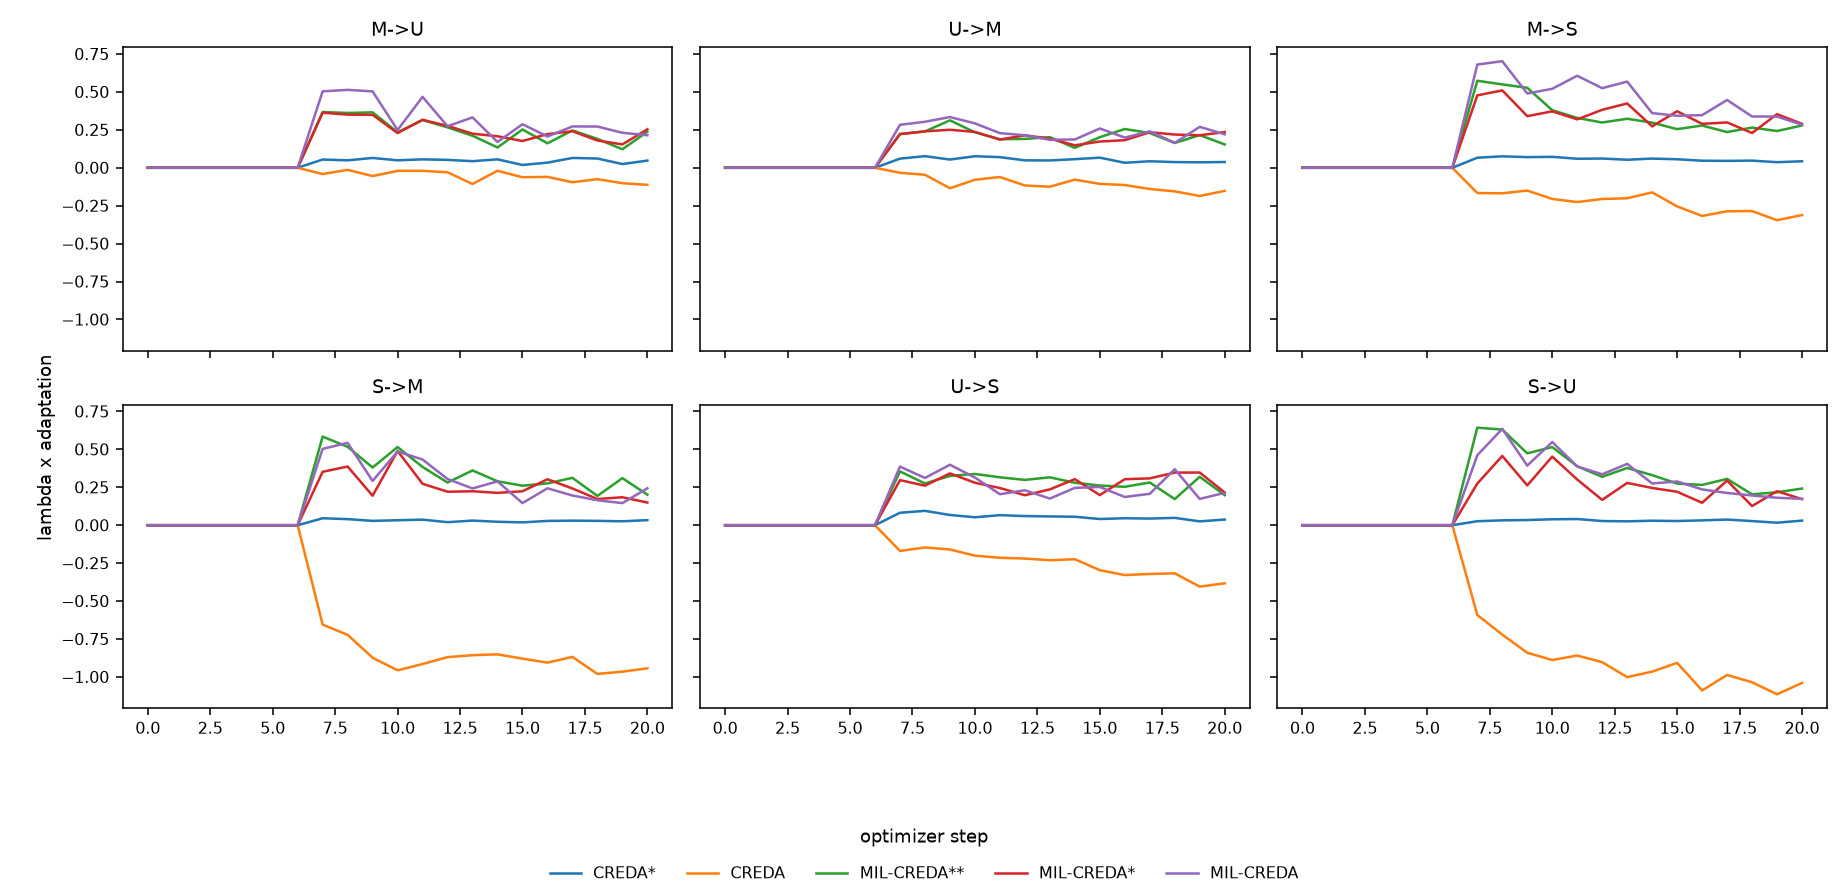

In [27]:
# Se muestra y se guarda en la misma llamada: la copia vectorial queda en Results
# y el cuaderno muestra la imagen, no su nombre de archivo.
display(figures.inline(figures.contribution_curves(config.RESULTS / "curves" / "contribution.pdf")))

## 7 · El registro

Escribe las mismas tablas y conclusiones de arriba en `report.txt` y `report.md`, y
al lado `runs.jsonl` y `summary.json`, que son lo que lee la fase dos. Una sesión
posterior tiene que poder saber que esta corrida ocurrió, bajo qué reducción y contra
qué revisión, y nada de eso vive fuera del repositorio. Se genera junto con los
resultados y nunca se escribe a mano: un resumen escrito a mano es una segunda fuente
de verdad, se desactualiza en silencio y se le cree igual.

In [28]:
bloques = [
    harness.header(reduction),
    tables.stamp(summary["reduction"]),
    tables.render(runs, "seconds", summary["reduction"]),
    tables.conclusion(runs, "seconds", summary["reduction"]),
    tables.render(runs, "sourceAccuracy", summary["reduction"]),
    tables.conclusion(runs, "sourceAccuracy", summary["reduction"]),
    tables.render_rungs(summary, "sourceAccuracy"),
    tables.conclusion_rungs(summary, "sourceAccuracy"),
    tables.render(runs, "targetAccuracy", summary["reduction"]),
    tables.conclusion(runs, "targetAccuracy", summary["reduction"]),
    tables.render_rungs(summary, "targetAccuracy"),
    tables.conclusion_rungs(summary, "targetAccuracy"),
]
(config.RESULTS / "report.txt").write_text("\n\n".join(bloques), encoding="utf-8")

(config.RESULTS / "report.md").write_text("\n\n".join([
    f"# Fase uno — {config.REVISION}",
    tables.stamp(summary["reduction"], markdown=True),
    "## 1 · Tiempo de entrenamiento (más bajo es mejor)",
    tables.render(runs, "seconds", summary["reduction"], markdown=True),
    tables.conclusion(runs, "seconds", summary["reduction"]),
    "## 2 · Exactitud en fuente (más alto es mejor)",
    tables.render(runs, "sourceAccuracy", summary["reduction"], markdown=True),
    tables.conclusion(runs, "sourceAccuracy", summary["reduction"]),
    "### 2b · Peldaños en fuente",
    tables.render_rungs(summary, "sourceAccuracy", markdown=True),
    tables.conclusion_rungs(summary, "sourceAccuracy"),
    "## 3 · Exactitud en destino (más alto es mejor)",
    tables.render(runs, "targetAccuracy", summary["reduction"], markdown=True),
    tables.conclusion(runs, "targetAccuracy", summary["reduction"]),
    "### 3b · Peldaños en destino",
    tables.render_rungs(summary, "targetAccuracy", markdown=True),
    tables.conclusion_rungs(summary, "targetAccuracy"),
]), encoding="utf-8")

print("escritos:")
for path in sorted(config.RESULTS.iterdir()):
    print(" ", path.relative_to(config.REPOSITORY))

escritos:
  MIL-CREDA/Results/Benchmark/curves
  MIL-CREDA/Results/Benchmark/latent
  MIL-CREDA/Results/Benchmark/latent.json
  MIL-CREDA/Results/Benchmark/latent.md
  MIL-CREDA/Results/Benchmark/report.md
  MIL-CREDA/Results/Benchmark/report.txt
  MIL-CREDA/Results/Benchmark/runs.jsonl
  MIL-CREDA/Results/Benchmark/summary.json


In [29]:
# El sello: contra qué código corrió este informe. Sin él, un informe viejo y uno
# recién generado se ven idénticos y el viejo se sigue creyendo.
from MIL_CREDA_Benchmark import report_digest

print(report_digest.stamp())

SOURCES-SHA256 9a8a461e7bfc68d7cb7260151f34c30e5e8224586e8e2dd30fc7b4fd19a58c82
